In [1]:
import ResultsReader as RR

The name of the table/CSV file containing the plate data.

In [2]:
filename = "./testingCSV2.txt"

Time break size is the number of seconds between data point reads before an automatic time break is created.

These automatic time breaks are meant to represent times whent the plate reader has been taken out, and factors in to heat correction.

Since our machine records data every 60 seconds, we can set our time break size to be anything above that.


In [3]:
timeBreakSize = 120

Inside and outside plate reader temperatures. Only needs to be set if using heatCorrections.


In [4]:
plateReaderTemp = 37
roomtemp = 20

Arbitray time unit. Used for labels on graphs.
Can be "s", "m", or "h"

In [5]:
timeUnit = "s" # "s", "m", "h"

We are going to be using a table, as it is the default output of a cytation 5 machine, so we set csv to false.


In [6]:
csv = False

Finally, can initialize the results reader.

In [7]:
resultsObj:RR.ResultsReader = RR.ResultsReader(filename, "notebook_output", timeBreakSize, plateReaderTemp, roomtemp, heatCorrect = True, timeUnit = timeUnit, csv = csv)

From here, we can perform any results readers functions. The following will be a series of example tasks that can be completed. At the end of each task, the plot function is called to visualize how it affected the data.

 First, let's plot the data as is, with the heat corrections and time breaks automatically applied. 

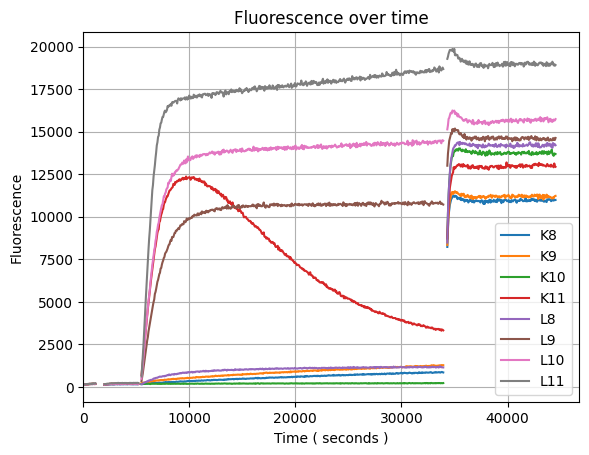

In [8]:
resultsObj.showDataSeriesByTime() 

Well removal

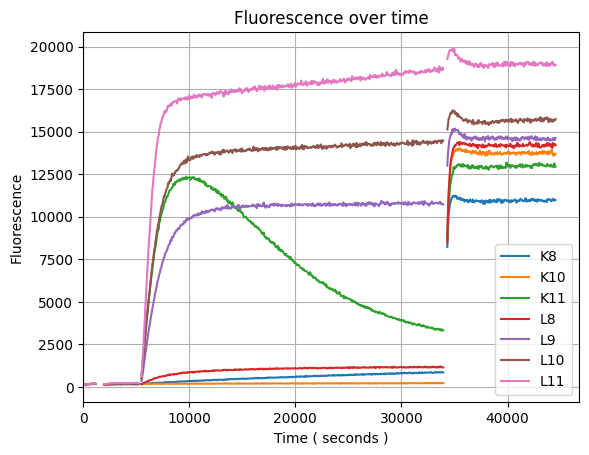

In [9]:
resultsObj.removeWell("K9")
resultsObj.showDataSeriesByTime() 

Removing a certain portion of data from the wells "L9 and L11", using an index based approach.

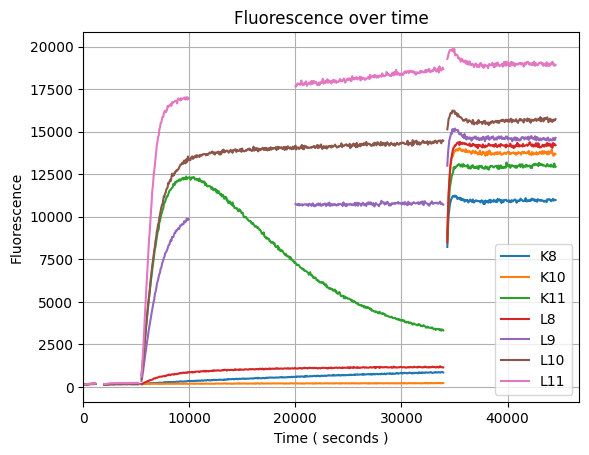

In [10]:
resultsObj.addTimeBreak(30000, columnName=["L9", "L11"])
resultsObj.addTimeBreak(20000, columnName=["L9", "L11"])
resultsObj.addTimeBreak(10000, columnName=["L9", "L11"])

resultsObj.voidTimeSpansByIndex(startBound = 3, endBound=4, columnName=["L9", "L11"])
resultsObj.showDataSeriesByTime() 

Removing portion of data from all wells using a time interval. Specifically, removing all data from [15000, 25000). **Note, end bounds are not inclusive.**

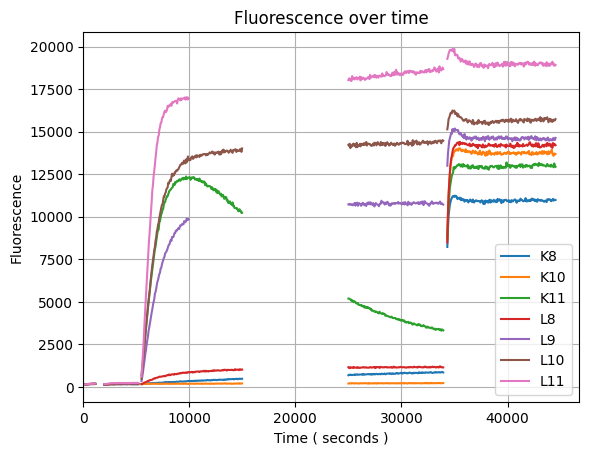

In [11]:
resultsObj.voidTimeSpansByTimeInterval(startBound=15000, endBound=25000) 
resultsObj.showDataSeriesByTime()

Same as above, but a different interval spanning two time breaks.

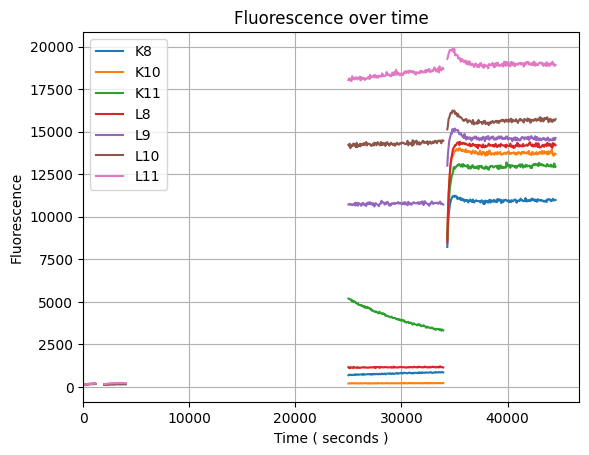

In [12]:
resultsObj.voidTimeSpansByTimeInterval(startBound=4000, endBound=20000) 
resultsObj.showDataSeriesByTime()

Demonstration that trying to remove data that does not exist does not do anything.

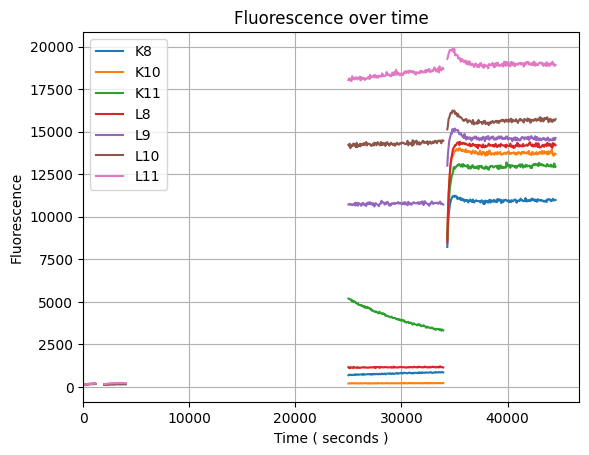

In [13]:
resultsObj.voidTimeSpansByTimeInterval(startBound=4000, endBound=20000) 
resultsObj.showDataSeriesByTime()

Set the "low values" for all wells, a.k.a what we are taking to be 0 for fluorescense, based on indexes of break intervals. In this case, we are only considering the first 2 time intervals for setting our low vals.

**Note: Only has effect on graphing if both low and high values for a well are set**

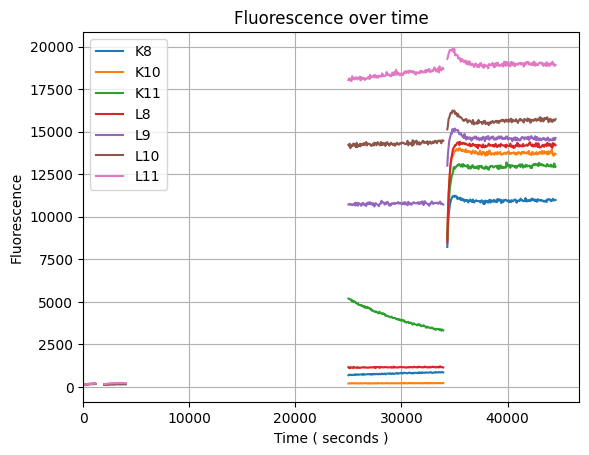

In [14]:
resultsObj.setLowValuesByBreakInterval(endBound = 2, percentile=10)
resultsObj.showDataSeriesByTime()

Set the high values for L11 only, demonstrating two plot graph.

In [15]:
resultsObj.setHighValuesByTimeInterval(startBound = 90 * 60, percentile=90, columnName = "L11")

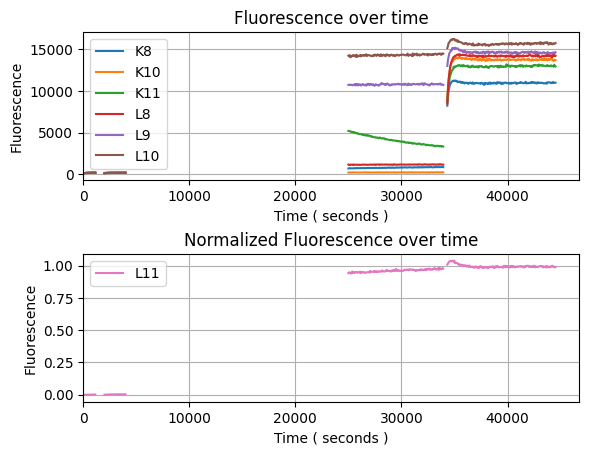

In [16]:
resultsObj.showDataSeriesByTime()

This is setting the high values for wells "K8" and "K10" based on the high value of "L11". This is useful when a well cannot reach its max fluorescence, but it is known that another well contains the maximum fluorescense value. 

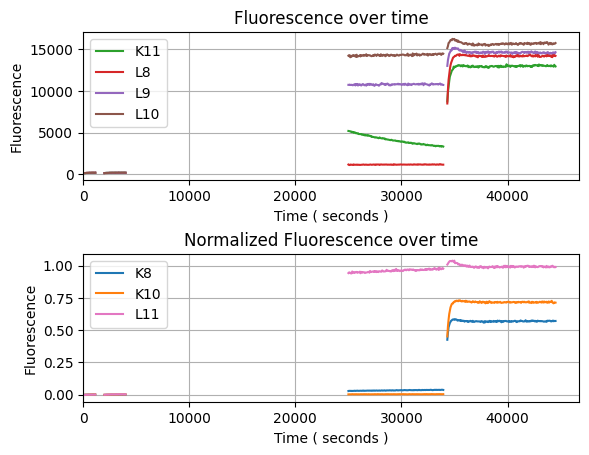

In [17]:
resultsObj.setHighUsingDifferentWell(settingWell="L11", columnName=["K8", "K10"])
resultsObj.showDataSeriesByTime() 

Individual well data can be recovered as a list of series. Can recover as normed or non normed data if high low vals have already been set. Also if high low has been set, can recover the normalized data as inverted values, which is useful if the high fluorescense corresponds to low concentration of the compound of interest.

In [18]:
test = resultsObj.getWellData("L11")

Save data saves all of the current data to the output folder in a csv format.

In [19]:
resultsObj.saveData("./testOutput.csv")

Set the high values for the well "L11" based on the data found in a set time interval. In this case, any time after minute 90.

**Note: Now that L11 has both high and low set, its values will be automatically normalized when plotting or saving data. This can be disabled as an argument when saving data.**